Assignment 3:

Name: Nishad Wajge

UID: 199578728

Please submit to ELMS
- a PDF containing all outputs (by executing **Run all**)
- your ipynb notebook containing all the code

I understand the policy on academic integraty (collaboration and the use of online material).
Please sign your name here: Nishad Wajge

In [1]:
## Import necessary libraries here (You can add libraries you want to use here)
import os
import random
import cv2
import numpy as np
import math
from scipy.io import loadmat
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline

from scipy.ndimage import gaussian_filter as gf



# Part 1: Homography Estimation with RANSAC (45 Points)


## Overview

In this problem, you will implement an algorithm for estimating homography (projective transformation) with RANSAC, using given point correspondences between two images.

A homography can describe the relationship between two images (1) of the same planar surface viewed from different camera positions, or (2) any two images taken by a cmaera rotating about its optical center (i.e., camera center does not move).

A homography is represented by a 3x3 matrix $\mathbf{H}$, mapping between any point correspondence between two images, $(x_i, y_i)$ and $(x'_i, y'_i)$:

$$\begin{bmatrix}
x'_i \\
y'_i \\
1 \\
\end{bmatrix} \sim
\begin{bmatrix}
h_1 & h_2 & h_3 \\
h_4 & h_6 & h_6 \\
h_7 & h_8 & h_9 \\
\end{bmatrix}
\begin{bmatrix}
x_i \\
y_i \\
1 \\
\end{bmatrix},$$

where
1. The $[x_i, y_i, 1]^\intercal$ denotes the homogeneous coordinates of the point $(x_i, y_i)$.
2. The $\sim$ deontes equality up to a non-zero scale factor.
It means that when you multiply $\mathbf{H}$ with $[x_i, y_i, 1]^\intercal$, you will obtain a 3x1 vector $[w'_i x'_i, w'_i y'_i, w'_i]^\intercal$. Therefore, to get the final transformed 2D point, you will have to divide the vector by the last entry, $w'_i$, into $[x'_i, y'_i, 1]^\intercal$.
3. Since $\mathbf{H}$ is defined up to scale, it has 8 degrees of freedom, requiring a minimum of 4 point correspondences to solve.

## Part 1.1 Applying homography transformation to points (5 points)

In [2]:
def transform_points(points, H):
    """Apply homography transform to a set of points.
    You cannot use cv2.perspectiveTransform for this part. You need to implement the transformation yourself.

    Args:
        points: np.ndarray of shape (n, 2) representing n points in 2D space.
        H: np.ndarray of shape (3, 3) representing the homography matrix.

    Returns:
        np.ndarray of shape (n, 2) representing the transformed points.
    """
    # Step 1: Convert points to homogeneous coordinates -> make it to  (n, 3) where the last column is 1
    # TODO: your code here
    # points_hm = ...  # (n, 3)
    points_hm = np.hstack((points, np.ones((points.shape[0], 1))))

    # Step 2: Apply the homography transformation pt_hm' = H @ pt_hm
    # to process all n points together, you would need to be careful about the dimensions of the matrices.
    # You can choose either of the following options:
    # option 1: (n, 3) <- ((3, 3) @  (n, 3).T).T
    # option 2: (n, 3) <- (n, 3) @ (3, 3).T
    # TODO: your code here
    # transformed_points_hm = ...  # (n, 3)
    transformed_points_hm = points_hm @ H.T

    # Step 3: dividing the first two columns by the third column and discard the third column
    # to convert back to Cartesian coordinates (n, 2)
    # transformed_points = ... # (n, 2)
    transformed_points = transformed_points_hm[:, :2] / transformed_points_hm[:, 2:]

    return transformed_points

### Unitest
You cannot modify the codes here

In [3]:
def check_close(points, H, transformed_points, tol=1e-5):
    transformed_points_cv2 = cv2.perspectiveTransform(points.reshape(-1, 1, 2), H).reshape(-1, 2)
    return np.allclose(transformed_points, transformed_points_cv2, atol=tol)

# test case 1:
points = np.array([[0, 0]], dtype=np.float32)
H = np.array([[1, 0, 10], [0, 1, 20], [0, 0, 1]], dtype=np.float32)
transformed_points = transform_points(points, H)
assert check_close(points, H, transformed_points), "Test case 1 failed!"

# test case 2:
points = np.array([[1, 2], [3, 4]], dtype=np.float32)
H = np.array([[2, 0, 0], [0, 2, 0], [0, 0, 1]], dtype=np.float32)
transformed_points = transform_points(points, H)
assert check_close(points, H, transformed_points), "Test case 2 failed!"

# test case 3:
points = np.array([[1, 1], [2, 2]], dtype=np.float32)
H = np.array([[0.2, 0.6, 0.8], [-0.1, 0.9, 0.5], [0.01, 0.02, 1]], dtype=np.float32)
transformed_points = transform_points(points, H)
assert check_close(points, H, transformed_points), "Test case 3 failed!"

print("All test cases passed!")

All test cases passed!


## Part 1.2 Direct Linear Transformation (DLT) (10 pt)

Given $n \geq 4$ point correspondences, each correspondence contributes the linear equations:
$$
x'_i = w'_i (h_1 x_i + h_2 y_i + h_3) \\
y'_i = w'_i (h_4 x_i + h_5 y_i + h_6) \\
1 = w'_i (h_7 x_i + h_8 y_i + h_9)\\
$$
Then, divide out the unknown scale factor $w'_i$ (devide line 1 and 2 by 3),
$$
x'_i (h_7 x_i + h_8 + y_i + h_9) = (h_1 x_i + h_2 y_i + h_3) \\
y'_i (h_7 x_i + h_8 + y_i + h_9) = (h_4 x_i + h_5 y_i + h_6) \\
$$
Rearrange the terms, it results in
$$
-h_1 x_i - h_2 y_i - h_3 + h_7 x_i x'_i + h_8 y_i x'_i + h_9 x'_i = 0 \\
-h_4 x_i - h_5 y_i - h_6 + h_7 x_i y'_i + h_8 y_i y'_i + h_9 y'_i = 0
$$
Finally, we can represent it in a matrix form:
$$ \mathbf{A}_i \boldsymbol{h} = \mathbf{0},$$
where $\mathbf{A}_i$ is a 2x9 matrix:
$$ \mathbf{A}_i = \begin{bmatrix}
-x_i & -y_i & -1 & 0 & 0 & 0 & x_i x'_i & y_i x'_i & x'_i \\
0 & 0 & 0 & -x_i & -y_i & -1 & x_i y'_i & y_i y'_i & y'_i
\end{bmatrix},
$$
and $\boldsymbol{h}$ is a 9x1 matrix:
$$
\boldsymbol{h} = \begin{bmatrix}h_1 & h_2 & h_3 & h_4 & h_5 & h_6 & h_7 & h_8 & h_9\end{bmatrix}^\intercal
$$
So far, we know that a point correspondence forms a matrix $\mathbf{A}_i$ with a shape of $2\times 9$.

Given $n$ point correspondences, we can stack multiple $\mathbf{A}_i$ into a big matrix $\mathbf{A}$ with a shape of $2n\times 9$, and $\mathbf{A}\boldsymbol{h} = \mathbf{0}$.

To solve $\boldsymbol{h}$ from $\mathbf{A}\boldsymbol{h}=\mathbf{0}$ with the known $\mathbf{A}$, we use Singular Value Decomposition (SVD):
$$
    \mathbf{A} = \mathbf{U}\mathbf{\Sigma}\mathbf{V}^\intercal,
$$
where each column of $\mathbf{V}$ represents a solution for $\mathbf{A}\boldsymbol{h}=\mathbf{0}$, and the corresponding eigenvalues represents the reprojection error. Therefore, we pick the last column of the $\mathbf{V}$ for $\boldsymbol{h}$ as its eigenvalue is the smallest. Finally, we reshape $\boldsymbol{h}$ into a 3x3 matrix $\mathbf{H}$.

In [4]:
# You cannot use built-in functions to estimate the homography matrix,
# but you can use built-in functions to perform matrix operations, such as SVD decomposition, etc.

def estimate_homography_dlt(src_pts, dst_pts):
    """
    Estimate the homography matrix using Direct Linear Transformation (DLT) algorithm.
    Args:
        src_pts: np.ndarray of shape (n, 2) representing source points (x_i, y_i)
        dst_pts: np.ndarray of shape (n, 2) representing destination points (x'_i, y'_i)
    Returns:
        H: np.ndarray of shape (3, 3) Estimated homography matrix
    """

    n = src_pts.shape[0]
    assert dst_pts.shape[0] == n, "Number of source and destination points must be the same."
    assert n >= 4, "At least 4 point correspondences are required to estimate the homography matrix."

    A = []

    # Step 1: Construct the 2x9 matrix A_i for a pair of corresponding points
    def construct_A_i(src_pt, dst_pt):
        """
        Args:
            src_pt: np.ndarray of shape (2,) representing (x_i, y_i) coordinates of the source point
            dst_pt: np.ndarray of shape (2,) representing (x'_i, y'_i) coordinates of the destination point
        Returns:
            A_i: np.ndarray of shape (2, 9) representing the contribution of the i-th point correspondence to the matrix A
        """
        # TODO: Your code here
        # A_i = ...  # (2, 9)
        x, y = src_pt
        xp, yp = dst_pt
        A_i = np.array([
            [-x, -y, -1,  0,  0,  0, xp*x, xp*y, xp],
            [ 0,  0,  0, -x, -y, -1, yp*x, yp*y, yp]
        ])

        return A_i

    # Step 2: Stack the A_i matrices returned from the construct_A_i function to form a 2n x 9 matrix A
    # TODO: Your code here
    # A = []
    # for ... in range(n): ...
    # A = np.concatenate(...)

    A = []
    for i in range(n):
      A.append(construct_A_i(src_pts[i], dst_pts[i]))

    A = np.concatenate(A, axis=0)

    # Step 3: Perform Singular Value Decomposition (SVD) on the matrix A
    # TODO: Your code here
    # ... = np.linalg.svd(A)
    U, S, Vt = np.linalg.svd(A)

    # Step 4: The homography matrix H is the last column of V (or the last row of V^T) reshaped to 3x3
    # TODO: Your code here
    # h = .... # The last column of V
    # H = ...  # Reshape h to 3x3
    h = Vt[-1, :]
    H = h.reshape(3, 3)

    # Step 5: Normalize the homography matrix H so that H[2, 2] = 1
    # TODO: Your code here
    # H = ...
    H = H / H[2, 2]

    return H

### Unitest
You cannot modify the codes here

Estimated homography matrix:
 [[ 4.31332827e-01 -7.34363130e-02  5.00000000e+01]
 [-7.34363130e-02  4.31332827e-01  5.00000000e+01]
 [-5.90866886e-04 -5.90866886e-04  1.00000000e+00]]
Test 1 passed!
Test 2 passed!


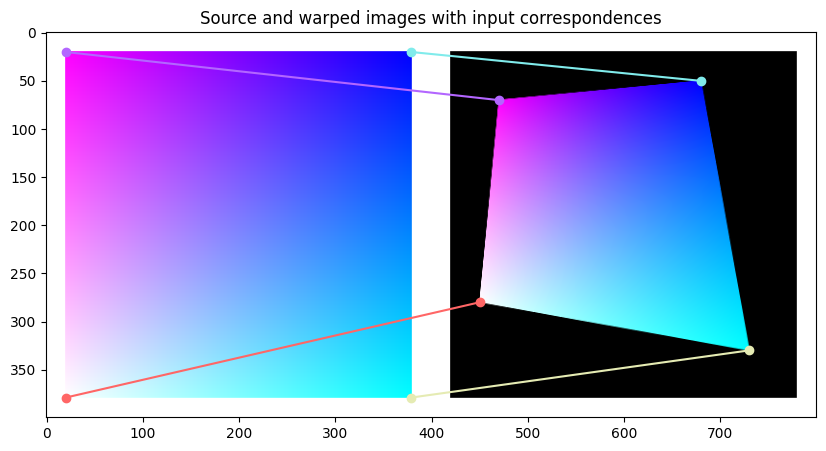

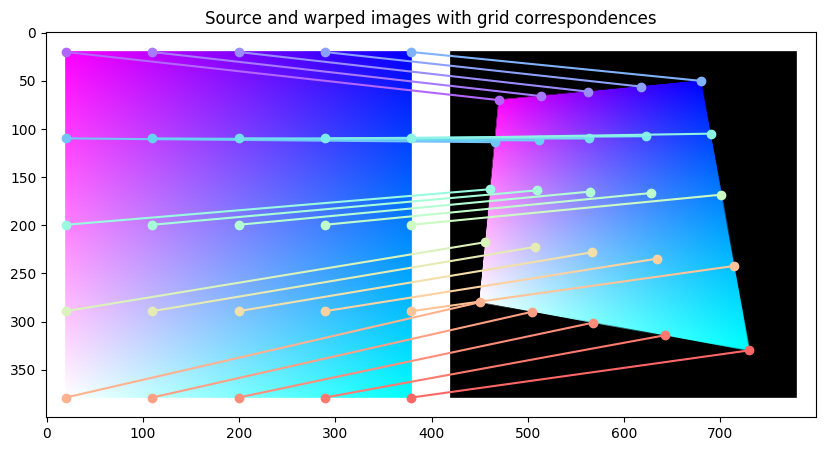

In [5]:
def create_color_gradient_sample(img_size):
    """
    Create a color gradient image with (img_size, img_size, 3).
    """
    x = np.linspace(0, 1, img_size)
    y = np.linspace(0, 1, img_size)
    xv, yv = np.meshgrid(x, y)
    img = np.stack([1 - xv, yv, np.ones_like(xv) * 1], axis=-1)
    return img

def visualize_warping_and_correspondence(src_img, tgt_img, src_pts, tgt_pts, title="Warping and Correspondences"):
    """
    Visualize the warping result and the correspondences between the source and target images.
    """
    fig, axes = plt.subplots(1, 1, figsize=(10, 5))
    axes.set_title(title)
    margin = 20
    src_img_with_margin = np.pad(src_img, ((margin, margin), (margin, margin), (0, 0)), mode='constant', constant_values=1)
    tgt_img_with_margin = np.pad(tgt_img, ((margin, margin), (margin, margin), (0, 0)), mode='constant', constant_values=1)
    combined_img = np.hstack((src_img_with_margin, tgt_img_with_margin))
    axes.imshow(combined_img)

    colors = cm.rainbow(np.linspace(0, 1, src_pts.shape[0])) * 0.6 + 0.4

    for i, (src_pt, tgt_pt) in enumerate(zip(src_pts, tgt_pts)):
        src_pt_with_margin = src_pt + margin
        tgt_pt_with_margin = tgt_pt + margin + np.array([src_img_with_margin.shape[1], 0])  # shift the target points to the right by the width of the source image
        axes.plot(src_pt_with_margin[0], src_pt_with_margin[1], color=colors[i], marker='o')  # plot source point in red
        axes.plot(tgt_pt_with_margin[0], tgt_pt_with_margin[1], color=colors[i], marker='o')  # plot target point in green
        axes.plot([src_pt_with_margin[0], tgt_pt_with_margin[0]], [src_pt_with_margin[1], tgt_pt_with_margin[1]], color=colors[i])  # draw a blue line between the corresponding points
    plt.show()

img_size = 360

src_img = create_color_gradient_sample(img_size)
src_pts = np.array([[0, 0], [img_size - 1, 0], [img_size - 1, img_size - 1], [0, img_size - 1]], dtype=np.float32)  # (x_i, y_i)
tgt_pts = np.array([[50, 50], [img_size - 100, 30], [img_size - 50, img_size - 50], [30, img_size - 100]], dtype=np.float32)  # (x'_i, y'_i)

H = estimate_homography_dlt(src_pts, tgt_pts)  # test your homography estimation function here
print("Estimated homography matrix:\n", H)

# test 1: apply the estimated homography to the source points and check if they are close to the target points
transformed_src_pts = transform_points(src_pts, H)
assert np.allclose(transformed_src_pts, tgt_pts, atol=1e-4), "Test 1 failed: Transformed source points are not close to target points."
print('Test 1 passed!')

# test 2: check if the transformed points are close to the target points using OpenCV's built-in function
H_cv2, _ = cv2.findHomography(src_pts, tgt_pts)
xs = np.linspace(0, img_size - 1, 5)
ys = np.linspace(0, img_size - 1, 5)
xv, yv = np.meshgrid(xs, ys)
src_pts_grid = np.stack([xv.flatten(), yv.flatten()], axis=-1)
transformed_points_cv2 = cv2.perspectiveTransform(src_pts_grid.reshape(-1, 1, 2), H_cv2).reshape(-1, 2)
transformed_points_dlt = transform_points(src_pts_grid, H)
assert np.allclose(transformed_points_dlt, transformed_points_cv2, atol=1e-4), "Test 2 failed: Transformed points from DLT are not close to OpenCV's perspectiveTransform."
print('Test 2 passed!')

# test 3: apply the estimated homography to the source image (color gradient) and visualize the result and the correspondences
# please check the reference result below
warped_img = cv2.warpPerspective(src_img, H, (img_size, img_size))
visualize_warping_and_correspondence(src_img, warped_img, src_pts, tgt_pts, title="Source and warped images with input correspondences")
visualize_warping_and_correspondence(src_img, warped_img, src_pts_grid, transformed_points_dlt, title="Source and warped images with grid correspondences")

#### Reference result

Reference homography matrix from OpenCV:
 [[ 4.31332827e-01 -7.34363130e-02  5.00000000e+01]
 [-7.34363130e-02  4.31332827e-01  5.00000000e+01]
 [-5.90866886e-04 -5.90866886e-04  1.00000000e+00]]


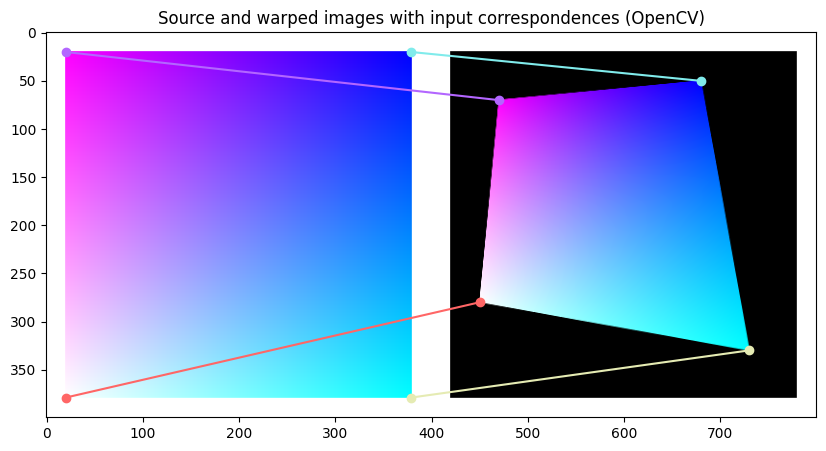

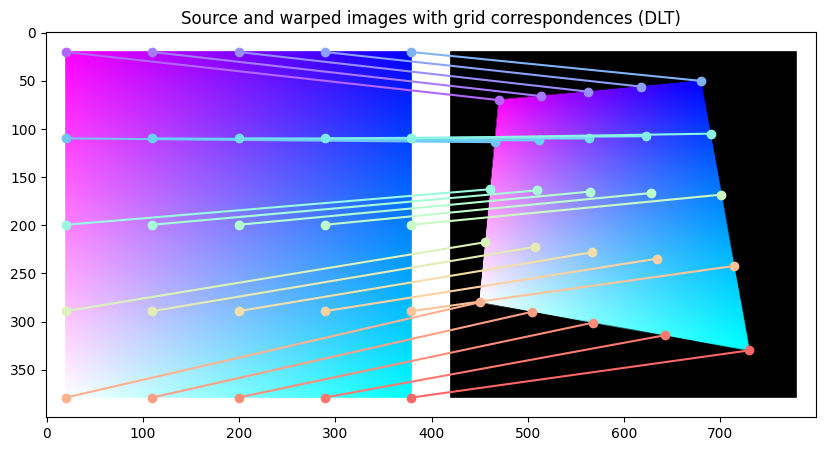

In [6]:
print("Reference homography matrix from OpenCV:\n", H_cv2)
warped_img_cv2 = cv2.warpPerspective(src_img, H_cv2, (img_size, img_size))
visualize_warping_and_correspondence(src_img, warped_img_cv2, src_pts, tgt_pts, title="Source and warped images with input correspondences (OpenCV)")
visualize_warping_and_correspondence(src_img, warped_img_cv2, src_pts_grid, transformed_points_cv2, title="Source and warped images with grid correspondences (DLT)")

## Part 1.3 Estimate homography with RANSAC (15 pt)
The DLT algorithm estimates a homography with $n$ correspondences, where $n \geq 4$.
While the DLT can run on a large set of point correspondences, those correpondences may be noisy–some may be false matches (i.e., outliers). Therefore, directly applying DLT on the whole correspondences may result in an inaccurate homography as the least square solution is affected by the outliers.

In this part, we are going to implemnt the RANSAC algorithm to handle outliers with robustness.

The RANSAC algorithm is an iterative process and has 3 steps in each iteration:
1. Randomly sample the number of points required to fit the model (#=4 for the homography model)
2. Solve the model (homography) parameters using samples
3. Score by the fraction of inliers within a preset threshold of the model

Repeat steps 1-3 until the best model is found with high confidence

We can simply use `np.random.choice` for step 1, and you have already implemented the function for step 2, estimate_homography_dlt.

Therefore, let's start with a mini function for step 3 to check whether each correspondence is an inlier using the estimated homography

In [7]:
def check_inliers(src_pts, tgt_pts, H, threshold=5.0):
    """
    Check which points are inliers given a homography matrix H and a set of point correspondences (src_pts, tgt_pts).
    Args:
        src_pts: np.ndarray of shape (n, 2) representing source points (x_i, y_i)
        tgt_pts: np.ndarray of shape (n, 2) representing destination points (x'_i, y'_i)
        H: np.ndarray of shape (3, 3) representing the homography matrix
        threshold: float, the distance threshold to determine if a point is an inlier
    Returns:
        inliers: np.ndarray of shape (n, ) boolean array where True indicates an inlier and False indicates an outlier
    """

    # step 1: apply the homography transformation to the source points to get the transformed points
    # TODO: your code here
    # transformed_pts = transform_points(...)  # (n, 2)
    transformed_pts = transform_points(src_pts, H)

    # step 2: compute the distances between the transformed points and the target points
    # please compute the Euclidean distance (L2 distance) between each pair of transformed point and target point
    # you cannot use built-in functions, such as np.linalg.norm, to compute the distance, you need to implement it yourself using basic numpy operations.
    # distances = ...  # (n,)
    distances = np.linalg.norm(transformed_pts - tgt_pts, axis=1)

    # step 3: determine which points are inliers based on the distance and the threshold
    inliers = distances <= threshold

    return inliers

#### Unitest
You cannot modify the codes here

In [8]:
# the correspondences are the same as before,
# but we additionally add a pair which is an outlier to test the inlier checking function
img_size = 360
src_pts = np.array([[0, 0], [img_size - 1, 0], [img_size - 1, img_size - 1], [0, img_size - 1], [img_size // 2, img_size // 2]], dtype=np.float32)  # (x_i, y_i)
tgt_pts = np.array([[50, 50], [img_size - 100, 30], [img_size - 50, img_size - 50], [30, img_size - 100], [0, 0]], dtype=np.float32)  # (x'_i, y'_i)

threshold = 2.0
H_cv2, inliers_cv2 = cv2.findHomography(src_pts, tgt_pts, method=cv2.RANSAC, ransacReprojThreshold=threshold)
inliers_cv2 = inliers_cv2.flatten().astype(bool)
inlier_mask_dlt = check_inliers(src_pts, tgt_pts, H_cv2, threshold=threshold)
print("Inlier mask from DLT:\n", inlier_mask_dlt)
print("Inlier mask from OpenCV's RANSAC:\n", inliers_cv2)
assert np.array_equal(inlier_mask_dlt, inliers_cv2), "Inlier mask from DLT does not match OpenCV's RANSAC inliers."
print("Inlier checking test passed!")

Inlier mask from DLT:
 [ True  True  True  True False]
Inlier mask from OpenCV's RANSAC:
 [ True  True  True  True False]
Inlier checking test passed!


Let's implement the entire RANSAC algorithm to find the homography

In [9]:
def estimate_homography_ransac(src_pts, dst_pts, num_iters=1000, threshold=5.0):
    """
    Estimate the homography matrix using RANSAC algorithm.
    Args:
        src_pts: np.ndarray of shape (n, 2) representing source points (x_i, y_i)
        dst_pts: np.ndarray of shape (n, 2) representing destination points (x'_i, y'_i)
        num_iters: int, the number of RANSAC iterations to perform
        threshold: float, the distance threshold to determine if a point is an inlier
    Returns:
        H: np.ndarray of shape (3, 3) representing the estimated homography matrix
        inlier_mask: np.ndarray of shape (n, ) boolean array where True indicates an inlier and False indicates an outlier
    """
    n = src_pts.shape[0]
    assert n >= 4, "At least 4 point correspondences are required to estimate the homography matrix."

    max_inliers = np.all(np.zeros(n, dtype=bool))  # (n,)

    for _ in range(num_iters):
        # step 1: Randomly sample 4 point correspondences to estimate the homography matrix
        # TODO: your code here
        # sample_indices = np.random.choice(...)  # (4, ), check the documentation of np.random.choice, also be careful about the `replace` argument.
        # sample_src_pts = ...  # (4, 2)
        # sample_dst_pts = ...  # (4, 2)
        sample_indices = np.random.choice(n, 4, replace=False)
        sample_src_pts = src_pts[sample_indices]
        sample_dst_pts = dst_pts[sample_indices]

        # step 2: estimate the homography using the sampled correspondences
        # TODO: your code here
        # H = estimate_homography_dlt(...)
        H = estimate_homography_dlt(sample_src_pts, sample_dst_pts)

        # step 3: check which points are inliers based on the estimated homography and the distance threshold
        # TODO: your code here
        # inliers = check_inliers(..., threshold=threshold)  # (n,)
        inliers = check_inliers(src_pts, dst_pts, H, threshold=threshold)

        # if the current homography has more inliers than the previous max one, update the max inlier mask
        # TODO: your code here:
        # if ...:
        #     max_inliers = inliers
        if np.sum(inliers) > np.sum(max_inliers):
          max_inliers = inliers

    # step 4: After all iterations, re-estimate the homography using all inliers from the best iteration (i.e., `max_inliers`)
    # we don't directly return the homography estimated from just 4 points
    # TODO: your code here
    # all_inlier_src_pts = ...
    # all_inlier_dst_pts = ...
    # best_H = ...
    all_inlier_src_pts = src_pts
    all_inlier_dst_pts = dst_pts
    best_H = estimate_homography_dlt(all_inlier_src_pts, all_inlier_dst_pts)

    return best_H, max_inliers


#### Unitest
You cannot modify the codes here

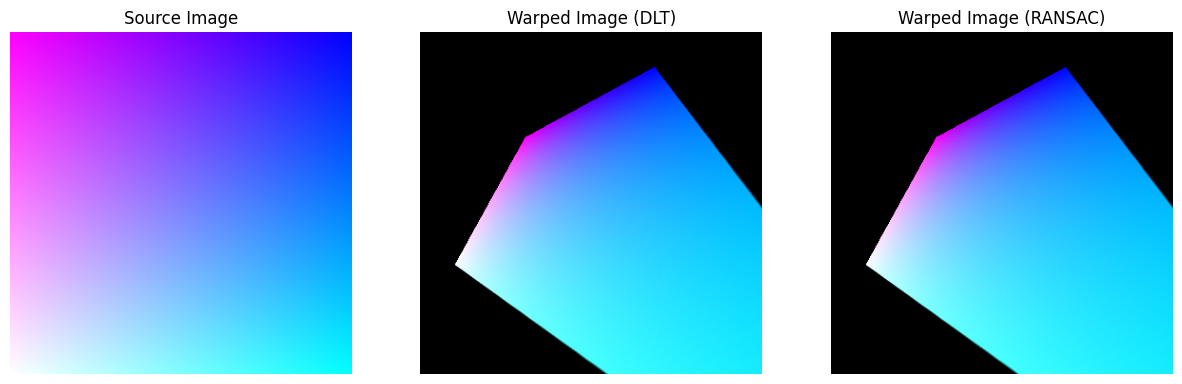

In [10]:
# the correspondences are the same as before,
# but we additionally add some bad pairs as outliers to test the ransac homography estimation function
img_size = 360
img = create_color_gradient_sample(img_size)
src_pts = np.array([[0, 0], [img_size - 1, 0], [img_size - 1, img_size - 1], [0, img_size - 1]], dtype=np.float32)  # (x_i, y_i)
tgt_pts = np.array([[50, 50], [img_size - 100, 30], [img_size - 50, img_size - 50], [30, img_size - 100]], dtype=np.float32)  # (x'_i, y'_i)

H_cv2, _ = cv2.findHomography(src_pts, tgt_pts)
xs = np.linspace(0, img_size - 1, 25)
ys = np.linspace(0, img_size - 1, 25)
xv, yv = np.meshgrid(xs, ys)
src_pts = np.stack([xv.flatten(), yv.flatten()], axis=-1)
tgt_pts = cv2.perspectiveTransform(src_pts.reshape(-1, 1, 2), H_cv2).reshape(-1, 2)

# add some outliers by randomly replacing some of the target points with random coordinates
num_outliers = int(0.25 * src_pts.shape[0])  # 25% of the points are outliers
np.random.seed(0)
outlier_indices = np.random.choice(src_pts.shape[0], size=num_outliers, replace=False)

src_pts[outlier_indices] += np.random.random((num_outliers, 2)) * img_size * 0.3 # randomly shift
tgt_pts[outlier_indices] += np.random.random((num_outliers, 2)) * img_size * 0.3 # randomly shift

threshold = 5.0
# your DLT homography estimation, it will be affected by the outlier
H_dlt = estimate_homography_dlt(src_pts, tgt_pts)

# your RANSAC homography estimation, it should be robust to the outlier and give you a better estimation than DLT
H_ransac, inliers_ransac = estimate_homography_ransac(src_pts, tgt_pts, num_iters=1000, threshold=threshold)

def compare_dlt_and_ransac(src_img, tgt_dlt, tgt_ransac):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].set_title("Source Image")
    axes[0].imshow(src_img)
    axes[0].axis('off')

    axes[1].set_title("Warped Image (DLT)")
    axes[1].imshow(tgt_dlt)
    axes[1].axis('off')

    axes[2].set_title("Warped Image (RANSAC)")
    axes[2].imshow(tgt_ransac)
    axes[2].axis('off')

# make sure the warped image by your RANSAC homography is aligned with the one by cv2's homography.
compare_dlt_and_ransac(
    src_img,
    cv2.warpPerspective(src_img, H_dlt, (img_size, img_size)),
    cv2.warpPerspective(src_img, H_ransac, (img_size, img_size)),
)


#### Reference

CV2 built-in homography estimation


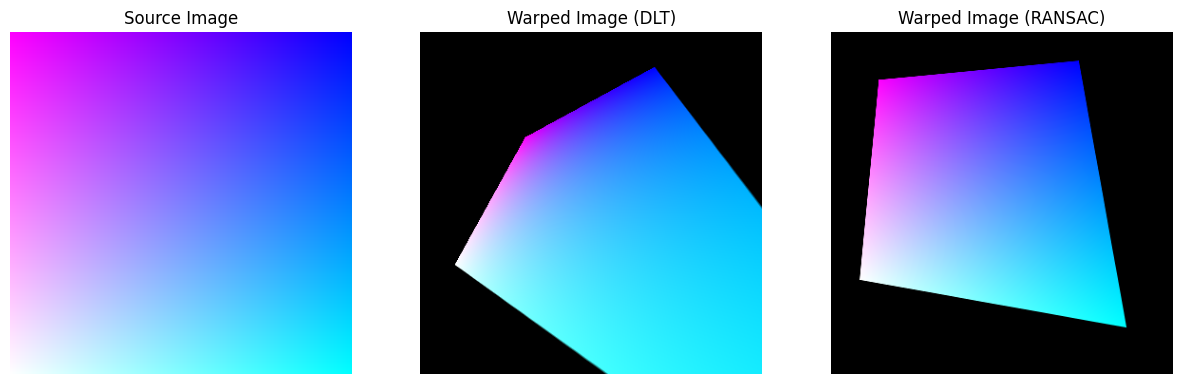

In [11]:
# CV2 built-in RANSAC homography estimation, it should give you a similar result as your RANSAC implementation
print("CV2 built-in homography estimation")
H_cv2_ransac, _ = cv2.findHomography(src_pts, tgt_pts, method=cv2.RANSAC, ransacReprojThreshold=threshold)
compare_dlt_and_ransac(
    src_img,
    cv2.warpPerspective(src_img, H_dlt, (img_size, img_size)),
    cv2.warpPerspective(src_img, H_cv2_ransac, (img_size, img_size)),
)

### Write-up (15 pt)
*   Explain why do we need at least 4 points to determine a homography matrix.

A homography matrix is a 3x3 transformation matrix that is in projective space. It has exactly eight degrees of freedom. Each pair of points gives us two linearly independent equations, meaning at least four point pairs is required to solve for the matrix's eight parameters.

*   Explain how the RANSAC algorithm handles outliers. How do you determine whether a correspondence is an outlier?

The RANSAC algorithm selects random subsets of four points to generate example models. It evaluates these models by applying the homography to the remaining points and calculating the error distance. If this error distance exceeds a threshold, it is deemed an outlier. RANSAC then selects the model that gives us the most inliers.

*   We use `cv2.warpPerspective()` to warp an image using a homography matrix. Please describe how it works.

Functions scuh as cv2.warpPerspective() rely on inverse warping to prevent empty gaps in the output image. The function iterates through each pixel in the destination image and applies the matrix to find its exact origin in the source image.


# Part 2: Image stitching (30 points)

<img src="https://www.cs.umd.edu/class/spring2023/cmsc426-0201/hw_images/image_stitching.png" width="800"/>

## Overview

In this problem, you will implement an algorithm for automatically estimating the fundamental matrix F using RANSAC and the normalized 8-point algorithm.

Image Stitching Algorithm Overview
1. Detect keypoints
2. Match keypoints
3. Estimate homography with matched keypoints (using RANSAC)
4. Combine images

**Note:**  Do not use existing image stitching code, such as found on the web, and OpenCV.

## Data

**WARNING: Colab deletes all files everytime runtime is disconnected. Make sure to re-download the inputs when it happens.**

In [12]:
# Download Data -- run this cell only one time per runtime
!gdown 1fnD0hJ8-_Rngsc-m96ghKtdZAMf0VTjy
!gdown 1v2BFVMV0McuD5BstLvDmo1U9MrFAByS5

### If you are running this notebook in Google Colab, please use the following code to unzip the downloaded files.
!unzip "/content/hill.zip" -d "/content/hill"
!unzip "/content/tv.zip" -d "/content/tv"

### If you are running this notebook in your local environment, please use the following code to unzip the downloaded files.
# !unzip hill.zip -d hill
# !unzip tv.zip -d tv


Downloading...
From: https://drive.google.com/uc?id=1fnD0hJ8-_Rngsc-m96ghKtdZAMf0VTjy
To: /content/hill.zip
100% 205k/205k [00:00<00:00, 6.09MB/s]
Downloading...
From: https://drive.google.com/uc?id=1v2BFVMV0McuD5BstLvDmo1U9MrFAByS5
To: /content/tv.zip
100% 130k/130k [00:00<00:00, 5.01MB/s]
Archive:  /content/hill.zip
  inflating: /content/hill/1.JPG     
  inflating: /content/hill/2.JPG     
  inflating: /content/hill/3.JPG     
Archive:  /content/tv.zip
  inflating: /content/tv/1.jpg       
  inflating: /content/tv/2.jpg       
  inflating: /content/tv/3.jpg       


### Hint


*   Use SIFT to find keypoint. You can use sift.detectAndCompute in opencv.
*   For image warping and blending, you should first deterimne canvas size. You can use cv2.warpPerspective in opencv.

An example is as follows:

<img src="https://www.cs.umd.edu/class/spring2024/cmsc426-0101/img/stitch.jpg" width="800"/>




## Helper Functions

In [13]:
import cv2

def drawMatches(image1, kp1, image2, kp2, idx_pairs):
    keypt1 = [cv2.KeyPoint(coord[1], coord[0], 40) for coord in kp1.tolist()]
    keypt2 = [cv2.KeyPoint(coord[1], coord[0], 40) for coord in kp2.tolist()]
    matches = [cv2.DMatch(pair[0], pair[1], 0) for pair in idx_pairs.tolist()]
    return cv2.drawMatches(image1, keypt1, image2, keypt2, matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

def plot_matches(images, feature_coord, matches, img_idx):
    matched_img = drawMatches(images[img_idx], feature_coord[img_idx], images[img_idx-1],
                              feature_coord[img_idx-1], matches[img_idx-1])

    cv2.imshow('Matches Found', matched_img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

def crop_blank(panorama):
    gray_panorama = cv2.cvtColor(panorama, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray_panorama, 1, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    max_area_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(max_area_contour)
    panorama = panorama[y:y+h, x:x+w]
    return panorama

def show_stitching(src_imgs, panorama):
    fig, axes = plt.subplots(1, len(src_imgs), figsize=(15, 5))
    for i in range(len(src_imgs)):
        axes[i].set_title(f"Source Image {i+1}")
        axes[i].imshow(src_imgs[i])
        axes[i].axis('off')
    plt.show()
    print()
    plt.figure(figsize=(15, 5))
    plt.imshow(panorama)
    plt.title(f"Panorama")
    plt.axis('off')
    plt.show()


### Code (10 pt)

In [14]:
def stitch_images(img1, img2, crop=True):
    """
    Warp img2 to img1 space and stitch them together to create a panorama image.
    Args:
        img1: np.ndarray of shape (H, W, 3) representing the first image (in BGR format)
        img2: np.ndarray of shape (H, W, 3) representing the second image (in BGR format)
        crop: bool, whether to crop out the blank borders in the stitched panorama
    Returns:
        panorama: np.ndarray representing the stitched panorama image (in BGR format)
    """
    # Please refer to the OpenCV's matching example (https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html) for step 1 and 2.

    # step 1: obtain sift keypoints and descriptors for both images
    sift = cv2.SIFT_create()
    keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
    keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

    # step 2: match keypoints
    index_params = dict(algorithm=1, trees=5)
    search_params = dict(checks=50)
    matcher = cv2.FlannBasedMatcher(index_params, search_params)
    matches = matcher.knnMatch(descriptors1, descriptors2, k=2)

    good_matches = []
    for m, n in matches:
        if m.distance < 0.3 * n.distance:
            good_matches.append(m)
            # each m is a cv2.DMatch object, which has attributes: queryIdx, trainIdx, imgIdx, distance.
            # Please check the documentation for more details: https://docs.opencv.org/4.x/d4/de0/classcv_1_1DMatch.html

    print("number of good matches: {}".format(len(good_matches)))

    if len(good_matches) > 4:
        # step 3: estimate homography with matched keypoints (using RANSAC)
        # TODO: your code here
        # src_pts = ...  # (n, 2), check how to extract the matching from good_matches to obtain points from the keypoints1 list
        # tgt_pts = ...  # (n, 2), check how to extract the matching from good_matches to obtain points from the keypoints2 list
        # H, _ = estimate_homography_ransac(...)  # (3, 3), be careful about the order of the source and target points. We want to warp img2 to img1 space.
        src_pts = np.float32([keypoints1[m.queryIdx].pt for m in good_matches]).reshape(-1, 2)
        tgt_pts = np.float32([keypoints2[m.trainIdx].pt for m in good_matches]).reshape(-1, 2)


        # define the canvas size for the panorama image
        pano_width = img1.shape[1] + img2.shape[1]
        pano_height = max(img1.shape[0], img2.shape[0])

        # step 4: combine images
        # Note that we want to warp img2 to img1 space
        # You can use `cv2.warpPerspective()` to warp images.
        # Be careful: do we use forward warping or backward warping? which homography matrix should we use? H_{img1->img2} or H_{img2->img1}?
        pano_img1 = np.zeros((pano_height, pano_width, 3), dtype=np.uint8)
        pano_img1[0:img1.shape[0], 0:img1.shape[1]] = img1
        # TODO: your code here
        # pano_img2 = cv2.warpPerspective(...)
        pano_img2 = cv2.warpPerspective(img2, H, (pano_width, pano_height))
        panorama = np.where(pano_img1.sum(axis=2, keepdims=True) > 0, pano_img1, pano_img2)  # simple blending by only keeping the warped img2 where img1 is blank.

        # Crop out the black right part if exists
        if crop:
            panorama = crop_blank(panorama)

        return panorama
    else:
        print("Not enough matches are found - %d/%d" % (len(good_matches), 5))
        return None


In [15]:
def stitch_multiple_images(images):
    # Check if there are at least two images to stitch
    if len(images) < 2:
        print("Need at least two images to stitch a panorama.")
        return None

    # Start stitching from the second-to-last image to the first
    stitched_image = images[-2]  # Start with the second-to-last image (e.g., img4 if we have img1...img5)
    for i in range(len(images) - 1, 0, -1):  # Iterate backwards starting from the last image
        print(f"Stitching image {i} on the right of image {i-1}")
        stitched_image = stitch_images(stitched_image, images[i], crop=False)
        if stitched_image is None:
            print(f"Failed to stitch image {i} into the panorama.")
            return None

    # Finally, stitch the result with the first image in the list
    stitched_image = stitch_images(images[0], stitched_image, crop=True)
    if stitched_image is None:
        print("Failed to stitch the final image into the panorama.")
        return None

    return stitched_image


In [16]:
 # TODO: change this to your local path if you are running in your local environment
root_dir = "/content/"  # e.g., "./" if you are running in your local environment and the images are in the same folder as this notebook

def load_images(case_name, exts=["jpg", "JPG"]):
    imgs = []
    for ext in exts:
        img_paths = sorted(glob.glob(os.path.join(root_dir, case_name, "*." + ext)))
        for img_path in img_paths:
            img = cv2.imread(img_path)[..., ::-1]  # read in BGR format and convert to RGB format
            imgs.append(img)
    return imgs

### Check two images stiching

number of good matches: 355
(300, 400, 3)


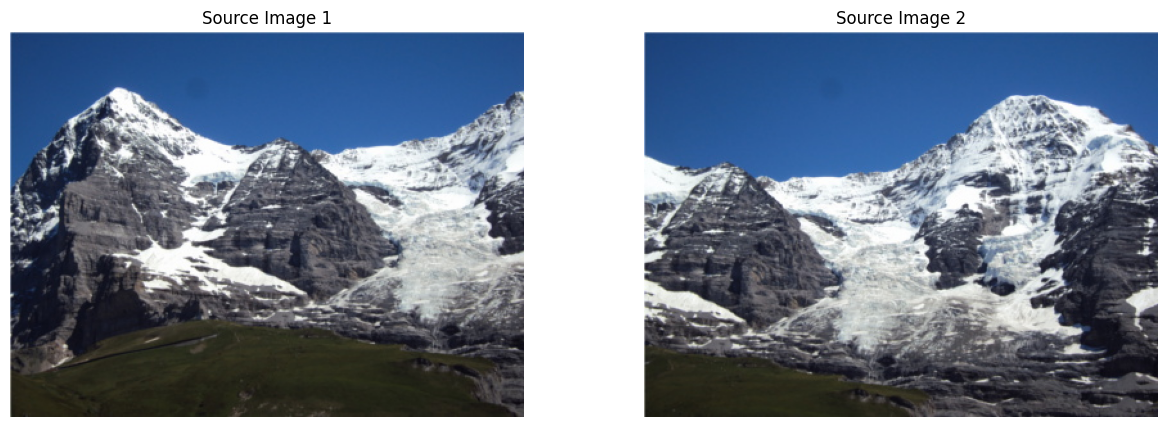

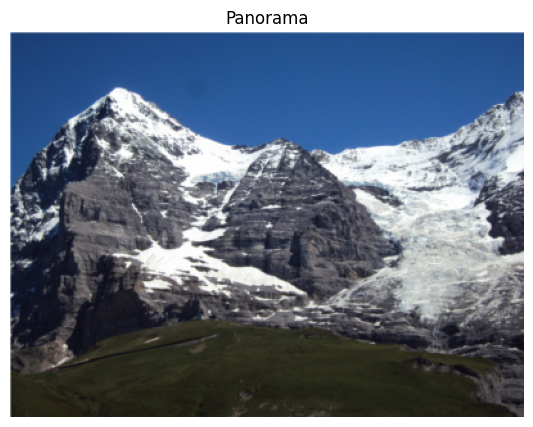

In [17]:
# Let's first try two images.
import glob

case_name = "hill"
imgs = load_images(case_name)

stitched_12 = stitch_images(imgs[0], imgs[1])
print(stitched_12.shape)

# display stitched image
# from google.colab.patches import cv2_imshow
# cv2_imshow(stitched_12)
show_stitching(imgs[:2], stitched_12)

# Stitch all three images
Let's stitch all three images in `hill`.

number of images to stitch: 3
Stitching image 2 on the right of image 1
number of good matches: 497
Stitching image 1 on the right of image 0
number of good matches: 1459
number of good matches: 357


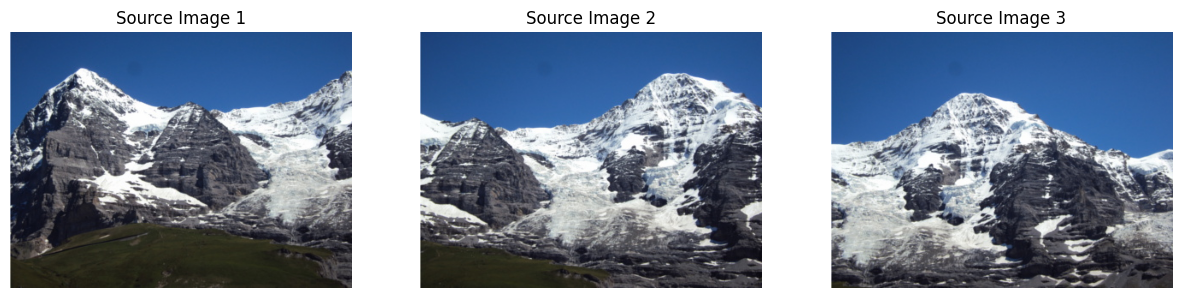

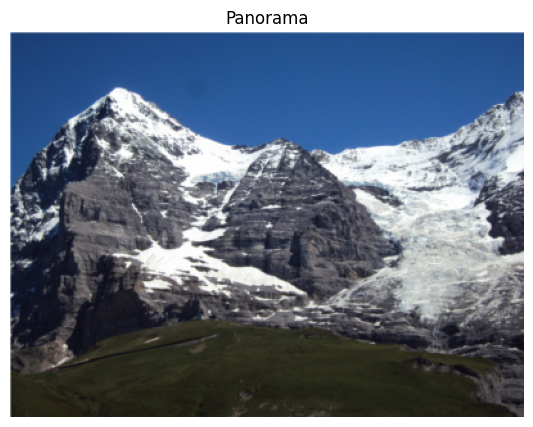

In [18]:
# Load your images in order
case_name = "hill"
imgs = load_images(case_name)
print("number of images to stitch: {}".format(len(imgs)))

# Stitch the images together into a panorama
panorama = stitch_multiple_images(imgs)

# display stitched image
show_stitching(imgs, panorama)

#Stich images for TV

number of images to stitch: 3
Stitching image 2 on the right of image 1
number of good matches: 44
Stitching image 1 on the right of image 0
number of good matches: 412
number of good matches: 27


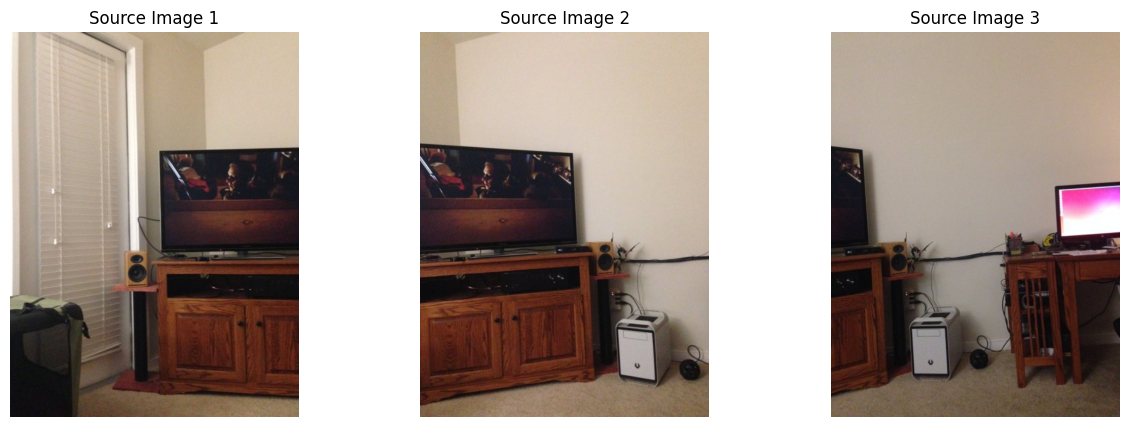

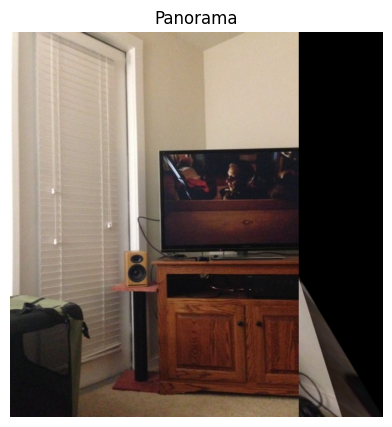

In [19]:
# Now stitch images for `tv`.
# Sometimes we will get bad stitching due to RANSAC
# Reducing thresh in keypoint match might help.

import glob
case_name = "tv"
imgs = load_images(case_name)
print("number of images to stitch: {}".format(len(imgs)))

# Stitch the images together into a panorama
panorama = stitch_multiple_images(imgs)

# display stitched image
show_stitching(imgs, panorama)

### Write-up (20 pt)
*  Display the stitched panorama results in the above blocks.

[Done]

*  Explain what the codes are doing in the step 2 of `stitch_images()`. How do we get good matches?
    ```
    matches = matcher.knnMatch(descriptors1, descriptors2, k=2)

    good_matches = []
    for m, n in matches:
        if m.distance < 0.3 * n.distance:
            good_matches.append(m)
    ```

In the matching step, we used a kNN algorithm to find the two closest matches for each feature. We then apply Lowe's ratio test, keeping a match if less than 30% of the second-best distance. This gives us the best match and filters out false answers to provide a good set of inliers.

*  In the step 4 of `stitch_images()`, we combine the two images by simply taking pixels from the warped img2 only where img1 is blank. Please discuss whether there are better approaches to blending the two images in the panorama. (You do not need to write any code — just describe what you would do.)

Simply overwriting pixels is often too much as theyre might be change due to lighting and exposure. A better alternative might be a gradual transition across the overlap region.

* Compared to the `hill` case, the panorama of the `tv` case exhibits more distortion (e.g., the monitor on the right). Please discuss the potential causes of the distortion. Does the distance between the camera and the scene matter? Why?

Distortion in close-up scenarios like the "tv" case is due to the assumption of a perfectly rotating camera or perfectly flat scene. While far away scenes approximate a flat plane and camera shifts are negligible, close-up shots can have significant depth variations. Thusm, slight camera movements can make foreground and background objects to shift relative to one another.
